# MirrorQATopo — Topological Boundary Experiment

Comparing `mode='full'` (all genuine qubits always paired) against
`mode='random'` (50:50 chance per even layer of f2f vs f2g outcome).

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.transpiler import Target
from qiskit.quantum_info import Operator
from qiskit.circuit.library import CXGate
from qiskit_device_benchmarking.bench_code.mrb import MirrorQA, MirrorQATopo, QuantumAwesomeness
from qiskit_device_benchmarking.bench_code.mrb import TopoUtil
import os, random

SEED = 123
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

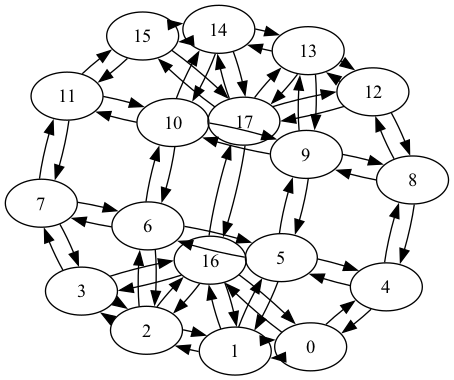

In [7]:
basis_gates = ["id", "h", "x", "y", "z", "rz", "cx"]
p2 = 1e-2
p1 = p2 / 10
rz_angle = np.pi / 2
# error rate for paper: 0.1, 1, 5%

shots = 1000
lengths = [2] + [4, 10, 20, 50]
num_samples = 100 # 100 for the paper (original notebook: 20)
num_lengths = len(lengths)

# Coupling map: 4x4 genuine lattice + 2 fake boundary qubits (18 nodes total)
cmap = TopoUtil.makeCouple(4, 4, 2, 'ibm')
num_qubits = len(list(cmap.physical_qubits))  # 18
legit_qubits = 16  # indices 0-15 are genuine; 16, 17 are fake
TopoUtil.checkCouple(cmap)

In [8]:
target = Target.from_configuration(
    num_qubits=num_qubits,
    basis_gates=basis_gates,
    coupling_map=cmap, # Give it the coupling map that we just created.
    custom_name_mapping={
        "id": Operator(np.eye(2)),
        "h":  Operator(np.array([[1, 1], [1, -1]]) / np.sqrt(2)),
        "x":  Operator(np.array([[0, 1], [1, 0]])),
        "y":  Operator(np.array([[0, -1j], [1j, 0]])),
        "z":  Operator(np.array([[1, 0], [0, -1]])),
        "rz": Operator([[np.cos(rz_angle/2), -1j*np.sin(rz_angle/2)],
                         [-1j*np.sin(rz_angle/2), np.cos(rz_angle/2)]]),
        "cx": Operator(np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]])),
    },
)

noise_model = NoiseModel()
error_1q = depolarizing_error(p1, 1)
error_2q = depolarizing_error(p2, 2)
for gate in basis_gates:
    if gate in ["id", "h", "x", "y", "z", "rz"]:
        noise_model.add_all_qubit_quantum_error(error_1q, gate)
    elif gate == "cx":
        noise_model.add_all_qubit_quantum_error(error_2q, gate)

In [9]:
backend = AerSimulator(
    method="stabilizer",
    noise_model=noise_model if (p1 > 0 or p2 > 0) else None,
    target=target,
    max_parallel_threads=0,
    max_parallel_experiments=0,
    seed_simulator=SEED,
)

Until above, everything is the same.<br/>
When we make the experiment object, give it 'full' or 'random' for `sampling_algorithm`.<br/>
For MirrorQATopo, there will be another parameter more than `sampling_algorithm`. <br/><br/>
The basic value for `sampling_algorithm` is `topo`, and within `topo`, there are two modes, either `full` or `random`. Choose either of those keywords.

```
makeCouple(num_rows, num_cols)
    └─▶ CouplingMap (genuine + fake edges)
            │
            ▼
    Target / Backend  (simulator knows about all 18 qubits)
            │
            ▼ MirrorQATopo(range(16), ...)
    _set_distribution_options()
    line 264: coupling_map.reduce(physical_qubits)   ← strips fake edges
            │
            ▼
    TopoSampler._select_edges_topo()
    — builds left/right columns algebraically from corners[1]+1
    — never reads fake-qubit connections from the coupling map
```

In [ ]:
exp = MirrorQATopo(
    range(legit_qubits),
    lengths=lengths,
    sampling_algorithm='topo',
    mode='full', # 'full': This mode is the same with NewSampler's behaviour.
    backend=backend,
    two_qubit_gate_density=0.5,
    num_samples=num_samples,
    initial_entangling_angle=np.pi / 2,
    seed=SEED,
)
exp.set_run_options(shots=shots)
rb_data = exp.run()
print(rb_data.job_ids)

for i in range(len(exp._pairs)):
    length = lengths[i % num_lengths]
    sample = i // num_lengths
    print(f"Circuit {i:3d} | length={length:3d}, sample={sample:2d}: "
          f"{len(exp._pairs[i])} pairs — {exp._pairs[i]}")

**Validation** — ground-truth outcome per circuit, derived from `exp._pairs` (sampler metadata, not MI).
- `f2f` if `len(pairs) == legit // 2` → all genuine qubits paired, nl–nr won the MWPM.
- `f2g` if `len(pairs) == legit // 2 − 1` → 2 genuine boundary qubits abandoned, nl/nr paired with boundary instead.

This oracle is **not** available to the bot — the bot can only see MI from measurement counts.

In [11]:
all_legit = set(range(legit_qubits))                                                                        
                                                                                                              
print(f"{'Circuit':>7} | {'length':>6} | {'sample':>6} | {'outcome':>6} | {'pairs':>5} | abandoned")        
print("-" * 65)                                                                                             
for i, pairs in enumerate(exp._pairs):                                                                      
    length  = lengths[i % num_lengths]                  
    sample  = i // num_lengths                                                                              
    paired  = {q for p in pairs for q in p}
    singles = set(exp._singles[i])                                                                          
    abandoned = all_legit - paired - singles            
                                                                                                              
    outcome = 'f2f' if len(pairs) == legit_qubits // 2 else 'f2g'
    print(f"  {i:5d} | {length:6d} | {sample:6d} | {outcome:>6} | "                                         
          f"{len(pairs):5d} | {sorted(abandoned) if abandoned else '-'}")

Circuit | length | sample | outcome | pairs | abandoned
-----------------------------------------------------------------
      0 |      2 |      0 |    f2f |     8 | -
      1 |      4 |      0 |    f2f |     8 | -
      2 |     10 |      0 |    f2g |     7 | [0, 14]
      3 |     20 |      0 |    f2f |     8 | -
      4 |     50 |      0 |    f2g |     7 | [3, 15]
      5 |      2 |      1 |    f2f |     8 | -
      6 |      4 |      1 |    f2f |     8 | -
      7 |     10 |      1 |    f2f |     8 | -
      8 |     20 |      1 |    f2f |     8 | -
      9 |     50 |      1 |    f2f |     8 | -
     10 |      2 |      2 |    f2f |     8 | -
     11 |      4 |      2 |    f2f |     8 | -
     12 |     10 |      2 |    f2g |     7 | [0, 14]
     13 |     20 |      2 |    f2f |     8 | -
     14 |     50 |      2 |    f2g |     7 | [1, 13]
     15 |      2 |      3 |    f2g |     7 | [3, 15]
     16 |      4 |      3 |    f2g |     7 | [3, 15]
     17 |     10 |      3 |    f2f |     8 

**Standard analysis** — fit the effective-polarisation decay curve using `MirrorRBAnalysis`.

In [12]:
exp.analysis.set_options(analyzed_quantity="Effective Polarization")
analysis = exp.analysis.run(rb_data)

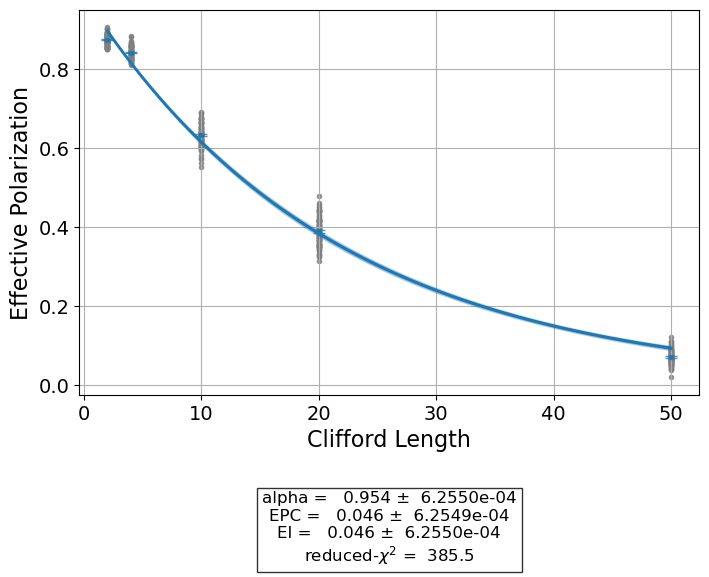

In [13]:
analysis.figure(0)

**MI analysis** — per-depth mutual information separated into *paired* (edge had an active CX in that circuit's first layer) vs *singles* (qubit had no 2Q partner).

`QuantumAwesomeness` takes the **genuine-only** coupling map — the fake boundary qubits (nl, nr) were never part of any circuit and must be excluded before computing MI.

/Users/astrydpark/miniconda3/envs/awesomeness/lib/python3.13/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/astrydpark/miniconda3/envs/awesomeness/lib/python3.13/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/astrydpark/miniconda3/envs/awesomeness/lib/python3.13/site-packages/numpy/_core/_methods.py:214: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/astrydpark/miniconda3/envs/awesomeness/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/astrydpark/miniconda3/envs/awesomeness/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype

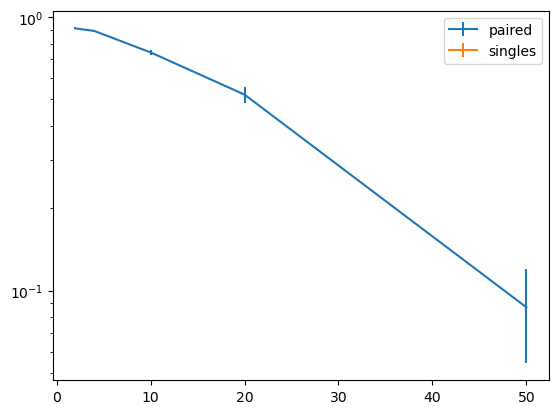

In [14]:
# [(j, k) for j, k in exp.backend.coupling_map if j < legit_qubits and k < legit_qubits]
# This can be easily written via qiskit.transpiler.CouplingMap.reduce().
# It will return the CouplingMap object, with the tuples (pairs) that we built.

legit_cmap = exp.backend.coupling_map.reduce(range(legit_qubits))
qa = QuantumAwesomeness(legit_cmap)

mi = qa.mutual_info(rb_data.data())
mmi = qa.mean_mutual_info(rb_data.data(), exp._pairs)

num_lengths = len(lengths)
ys = [[[] for _ in range(num_lengths)] for _ in range(2)]
yerrs = [[], []]

for p, pairtype in enumerate(["paired", "singles"]):
    for j, m in enumerate(mmi[pairtype]):
        if m is not np.nan:
            ys[p][j % num_lengths].append(m)
    for j in range(num_lengths):
        yerrs[p].append(np.std(ys[p][j]))
        ys[p][j] = np.mean(ys[p][j])

plt.errorbar(lengths, ys[0], yerr=yerrs[0], label="paired")
plt.errorbar(lengths, ys[1], yerr=yerrs[1], label="singles")
plt.yscale("log")
plt.legend()

### Bot!

In [15]:
import networkx as nx
from collections import defaultdict

# --------------------------------------------------------------------------
# The previous bot had maxcardinality=True, which forces exactly 8 matched
# pairs.  f2g circuits have 7 genuine pairs, so f2g was *structurally*
# undetectable: every f2g was a guaranteed miss, and the cardinality
# constraint caused a ripple that broke high-MI genuine pairs just to absorb
# the abandoned qubit.  The "accuracy" numbers were simply the f2f fraction
# per depth — random, not physics.
#
# Fix: maxcardinality=False.  MWPM now maximises total MI weight; abandoned
# qubits (near-zero MI with all neighbours) fall out of the matching
# naturally.  The bot can now predict the mode (f2f / f2g) and the pairs.
# --------------------------------------------------------------------------

half = legit_qubits // 2      # 8 pairs expected for a full f2f matching

correct_pairs_by_len = defaultdict(int)
correct_mode_by_len  = defaultdict(int)
total_by_len         = defaultdict(int)

for i, info in enumerate(mi):
    length = lengths[i % num_lengths]

    G = nx.Graph()
    for (u, v), w in info.items():        # u < v by construction from mutual_info
        G.add_edge(u, v, weight=w)

    guess        = nx.max_weight_matching(G, maxcardinality=False, weight="weight")
    truth        = set(tuple(sorted(p)) for p in exp._pairs[i])
    sorted_guess = set(tuple(sorted(a)) for a in guess)

    # ---------- derive modes and match quality ----------
    true_mode = 'f2f' if len(truth) == half else 'f2g'
    pred_mode = 'f2f' if len(sorted_guess) == half else 'f2g'
    pairs_ok  = sorted_guess == truth
    mode_ok   = true_mode == pred_mode

    # Mean MI of the bot's predicted pairs — a depth-sensitive signal quality
    # indicator: high at shallow depth (strong entanglement), decays with noise.
    matched_mi = [info[p] for p in sorted_guess if p in info]
    mean_mi    = np.mean(matched_mi) if matched_mi else float('nan')

    correct_pairs_by_len[length] += int(pairs_ok)
    correct_mode_by_len[length]  += int(mode_ok)
    total_by_len[length]         += 1

    # Three-way outcome: EXACT (pairs match), MODE (right f2f/f2g, wrong pair
    # assignment), MISS (wrong mode entirely).
    tag = 'EXACT' if pairs_ok else ('MODE ' if mode_ok else 'MISS ')
    print(
        f"[{i:3d}] L={length:3d} | truth={true_mode}  pred={pred_mode} [{tag}]"
        f"  #pairs truth={len(truth)}  bot={len(sorted_guess)}"
        f"  mean-MI={mean_mi:.4f}"
    )

print("\n=== Bot accuracy by circuit depth ===")
print(f"{'Length':>8} | {'P(exact)':>8} | {'P(mode)':>8} | {'Total':>6}")
print("-" * 38)
for length in lengths:
    t  = total_by_len[length]
    cp = correct_pairs_by_len[length]
    cm = correct_mode_by_len[length]
    print(f"{length:8d} | {cp/t:8.3f} | {cm/t:8.3f} | {t:6d}")


[  0] L=  2 | truth=f2f  pred=f2f [EXACT]  #pairs truth=8  bot=8  mean-MI=0.9024
[  1] L=  4 | truth=f2f  pred=f2f [EXACT]  #pairs truth=8  bot=8  mean-MI=0.8853
[  2] L= 10 | truth=f2g  pred=f2g [EXACT]  #pairs truth=7  bot=7  mean-MI=0.7327
[  3] L= 20 | truth=f2f  pred=f2f [EXACT]  #pairs truth=8  bot=8  mean-MI=0.5631
[  4] L= 50 | truth=f2g  pred=f2g [EXACT]  #pairs truth=7  bot=7  mean-MI=0.0939
[  5] L=  2 | truth=f2f  pred=f2f [EXACT]  #pairs truth=8  bot=8  mean-MI=0.9179
[  6] L=  4 | truth=f2f  pred=f2f [EXACT]  #pairs truth=8  bot=8  mean-MI=0.8958
[  7] L= 10 | truth=f2f  pred=f2f [EXACT]  #pairs truth=8  bot=8  mean-MI=0.7371
[  8] L= 20 | truth=f2f  pred=f2f [EXACT]  #pairs truth=8  bot=8  mean-MI=0.5737
[  9] L= 50 | truth=f2f  pred=f2f [EXACT]  #pairs truth=8  bot=8  mean-MI=0.0742
[ 10] L=  2 | truth=f2f  pred=f2f [EXACT]  #pairs truth=8  bot=8  mean-MI=0.9129
[ 11] L=  4 | truth=f2f  pred=f2f [EXACT]  #pairs truth=8  bot=8  mean-MI=0.8852
[ 12] L= 10 | truth=f2g  pre